# Swin-UNet: Pure Transformer for Polyp Segmentation

**Paper:** *Swin-Unet: Unet-like Pure Transformer for Medical Image Segmentation* (Cao et al., ECCVW 2022)

**Dataset:** Kvasir-SEG — 1,000 colonoscopy images with expert-annotated binary polyp masks

**Family 5: Pure Transformer — both encoder AND decoder contain zero convolutions.**

---

## What We Are Building

Swin-UNet is the first pure Transformer architecture to follow a U-Net style encoder-decoder structure with skip connections — but replacing every convolutional operation with Swin Transformer blocks.

Two key innovations over SETR (Family 3):

1. **Hierarchical encoder** — spatial resolution reduces progressively through Patch Merging, creating a feature pyramid like a CNN encoder — unlike SETR's flat ViT which keeps all tokens at the same resolution
2. **Pure Transformer decoder** — uses Patch Expanding layers (the mirror of Patch Merging) to upsample feature maps without any transposed convolutions

### Architecture Overview
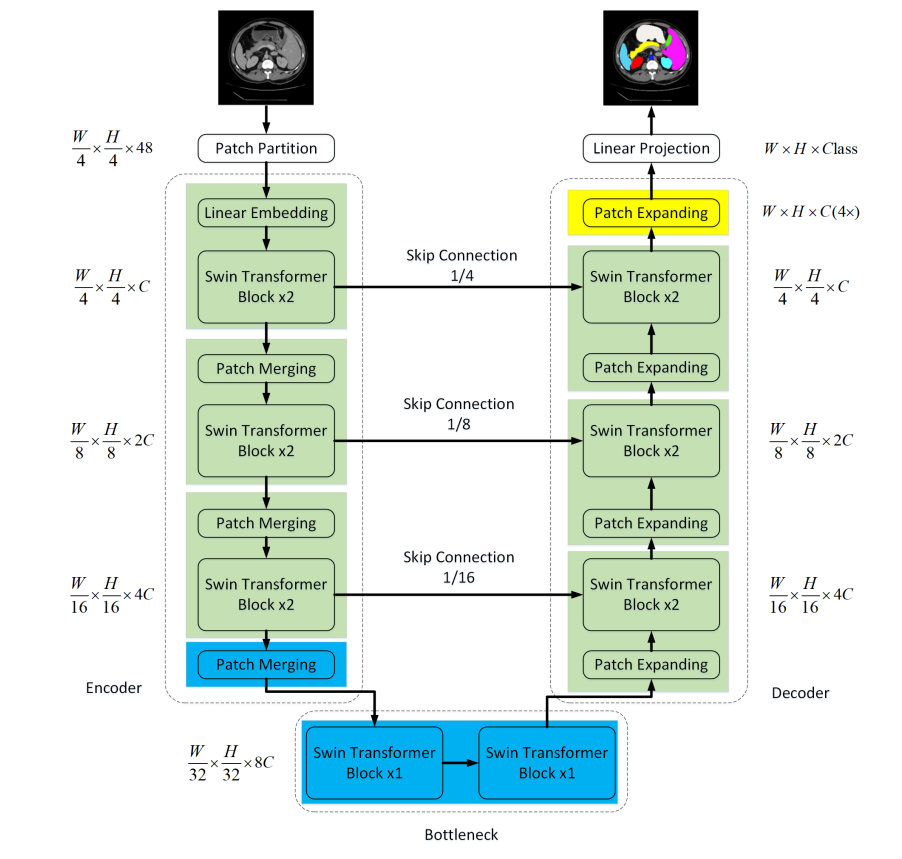

```
Input Image (3 × 224 × 224)
        ↓
Patch Partition  →  (56×56 tokens, 96-dim)
        ↓
Encoder Stage 1  →  2 × Swin Transformer Blocks  →  (56×56, 96)
        ↓  Patch Merging
Encoder Stage 2  →  2 × Swin Transformer Blocks  →  (28×28, 192)
        ↓  Patch Merging
Encoder Stage 3  →  6 × Swin Transformer Blocks  →  (14×14, 384)
        ↓  Patch Merging
Bottleneck       →  2 × Swin Transformer Blocks  →  (7×7,  768)
        ↓  Patch Expanding
Decoder Stage 3  →  2 × Swin Transformer Blocks  →  (14×14, 384) ← skip
        ↓  Patch Expanding
Decoder Stage 2  →  2 × Swin Transformer Blocks  →  (28×28, 192) ← skip
        ↓  Patch Expanding
Decoder Stage 1  →  2 × Swin Transformer Blocks  →  (56×56,  96) ← skip
        ↓  4× Patch Expanding
Segmentation Head  →  Linear projection
        ↓
Output Mask (1 × 224 × 224)
```


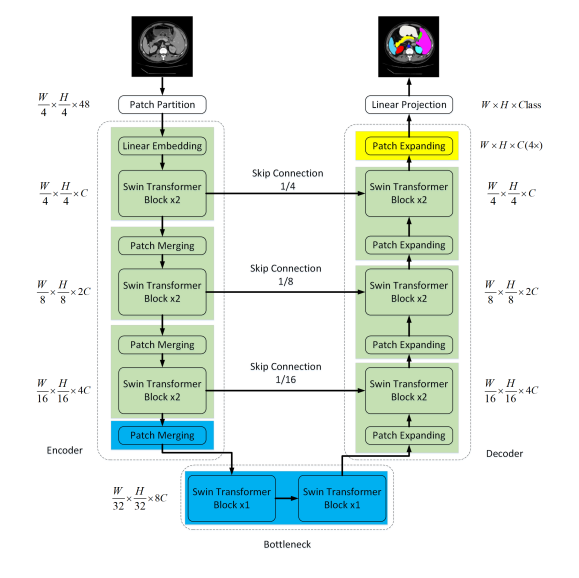

## Step 1: Install Dependencies

In [1]:
!pip install timm einops -q

## Step 2: Imports

In [2]:
import os
import random
import numpy as np
from PIL import Image
from glob import glob

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

import timm
from einops import rearrange
import matplotlib.pyplot as plt
from tqdm import tqdm

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## Step 3: Dataset Paths

Swin-UNet was originally designed for **224×224** inputs — we keep this size to stay compatible with the pretrained Swin-Tiny weights without any positional embedding interpolation.

The Kvasir-SEG dataset structure on Kaggle:
```
kvasir-seg/
├── images/       ← 1000 colonoscopy images (.jpg)
└── masks/        ← 1000 binary segmentation masks (.jpg)
```

> Update `DATA_ROOT` to match your Kaggle dataset path.

In [3]:
# ── Update this path to your Kaggle dataset location ──
DATA_ROOT = '/kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG'

IMAGE_DIR = os.path.join(DATA_ROOT, 'images')
MASK_DIR  = os.path.join(DATA_ROOT, 'masks')

image_paths = sorted(glob(os.path.join(IMAGE_DIR, '*.jpg')))
mask_paths  = sorted(glob(os.path.join(MASK_DIR,  '*.jpg')))

print(f'Total images : {len(image_paths)}')
print(f'Total masks  : {len(mask_paths)}')

for img, msk in zip(image_paths[:5], mask_paths[:5]):
    assert os.path.basename(img) == os.path.basename(msk), 'Filename mismatch!'
print('Filename pairing check passed ✓')

Total images : 1000
Total masks  : 1000
Filename pairing check passed ✓


## Step 4: Train / Validation / Test Split

Same 800/100/100 split as the SETR notebook — keeps comparisons fair.

In [4]:
combined = list(zip(image_paths, mask_paths))
random.shuffle(combined)
image_paths, mask_paths = zip(*combined)

train_images, train_masks = image_paths[:800],   mask_paths[:800]
val_images,   val_masks   = image_paths[800:900], mask_paths[800:900]
test_images,  test_masks  = image_paths[900:],    mask_paths[900:]

print(f'Train : {len(train_images)} | Val : {len(val_images)} | Test : {len(test_images)}')

Train : 800 | Val : 100 | Test : 100


## Step 5: Dataset & Augmentation

### Image Size: 224×224
Swin-Tiny uses 4×4 patch partitioning, producing 56×56 tokens at Stage 1. We use 224×224 to match the pretrained weight resolution exactly — no positional embedding interpolation needed.

### Augmentation
Identical strategy to the SETR notebook for fair comparison:
- Horizontal & Vertical flips
- Random rotation ±15°  
- Color jitter (image only)
- ImageNet normalization (required for pretrained Swin weights)

In [5]:
IMG_SIZE = 224

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


class PolypDataset(Dataset):
    """
    Kvasir-SEG Dataset.

    Returns:
        image : FloatTensor (3, H, W) — normalized with ImageNet stats
        mask  : FloatTensor (1, H, W) — binary {0.0, 1.0}
    """

    def __init__(self, image_paths, mask_paths, img_size=IMG_SIZE, augment=False):
        self.image_paths  = list(image_paths)
        self.mask_paths   = list(mask_paths)
        self.img_size     = img_size
        self.augment      = augment
        self.normalize    = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
        self.color_jitter = transforms.ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1
        )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        mask  = Image.open(self.mask_paths[idx]).convert('L')

        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask  = mask.resize((self.img_size, self.img_size),  Image.NEAREST)

        if self.augment:
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask  = TF.hflip(mask)
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask  = TF.vflip(mask)
            if random.random() > 0.5:
                angle = random.uniform(-15, 15)
                image = TF.rotate(image, angle, interpolation=Image.BILINEAR)
                mask  = TF.rotate(mask,  angle, interpolation=Image.NEAREST)
            if random.random() > 0.5:
                image = self.color_jitter(image)

        image = TF.to_tensor(image)
        mask  = TF.to_tensor(mask)
        image = self.normalize(image)
        mask  = (mask > 0.5).float()

        return image, mask


train_dataset = PolypDataset(train_images, train_masks, augment=True)
val_dataset   = PolypDataset(val_images,   val_masks,   augment=False)
test_dataset  = PolypDataset(test_images,  test_masks,  augment=False)

BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train batches : 100
Val   batches : 13
Test  batches : 13


## Step 6: Visualize a Sample

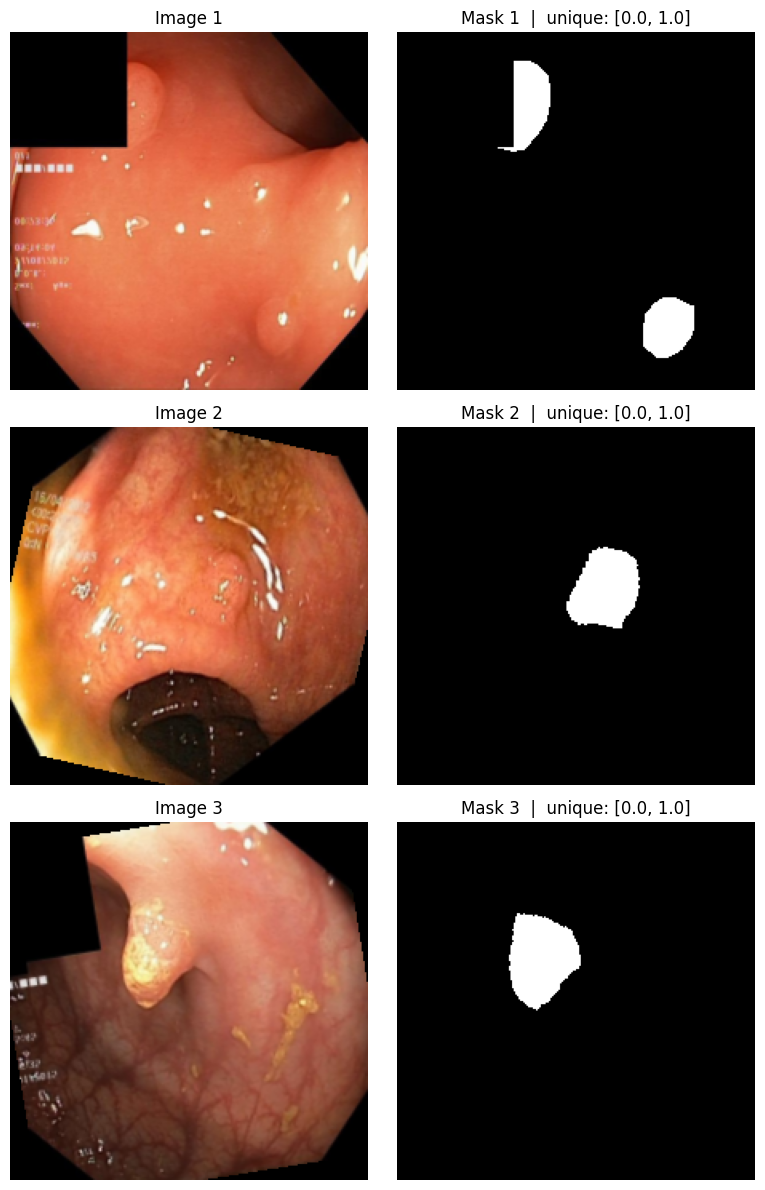

In [6]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


fig, axes = plt.subplots(3, 2, figsize=(8, 12))
for i in range(3):
    img, msk = train_dataset[i]
    axes[i, 0].imshow(denormalize(img).permute(1, 2, 0))
    axes[i, 0].set_title(f'Image {i+1}')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(msk.squeeze(), cmap='gray')
    axes[i, 1].set_title(f'Mask {i+1}  |  unique: {msk.unique().tolist()}')
    axes[i, 1].axis('off')
plt.tight_layout()
plt.show()

## Step 7: Swin-UNet Model

### Design Decisions
I implement Swin-UNet using **Swin-Tiny** pretrained on ImageNet-22k as the encoder backbone. The decoder mirrors the encoder symmetrically using:

- **Patch Expanding** — the inverse of Patch Merging. Takes (H×W, C) tokens and produces (2H×2W, C/2) tokens through linear projection and spatial rearrangement. No transposed convolutions — pure token manipulation.
- **Swin Transformer blocks** at each decoder stage
- **Skip connections** — concatenate matching encoder and decoder feature maps, then project back to expected channel dimension

### Encoder: Swin-Tiny Feature Pyramid

```
Stage 1: (56×56, 96)   ← skip connection 1
Stage 2: (28×28, 192)  ← skip connection 2  
Stage 3: (14×14, 384)  ← skip connection 3
Bottleneck: (7×7, 768)
```

### Decoder: Patch Expanding Pyramid

```
Bottleneck (7×7, 768)
  ↑ Patch Expand → (14×14, 384) + skip → Linear proj → (14×14, 384)
  ↑ Patch Expand → (28×28, 192) + skip → Linear proj → (28×28, 192)
  ↑ Patch Expand → (56×56,  96) + skip → Linear proj → (56×56,  96)
  ↑ 4× Patch Expand → (224×224, 96)
  → Linear(96 → 1) → segmentation mask
```

In [9]:
class PatchExpanding(nn.Module):
    """
    Patch Expanding Layer.
    Takes  : (B, H, W, C)   ← NHWC
    Returns: (B, 2H, 2W, C//2)
    """
    def __init__(self, dim):
        super().__init__()
        self.expand = nn.Linear(dim, 2 * dim, bias=False)
        self.norm   = nn.LayerNorm(dim // 2)

    def forward(self, x):
        # x: (B, H, W, C)
        x = self.expand(x)                              # (B, H, W, 2C)
        B, H, W, C = x.shape
        x = rearrange(x, 'b h w (p1 p2 c) -> b (h p1) (w p2) c',
                      p1=2, p2=2, c=C // 4)             # (B, 2H, 2W, C//2)
        x = self.norm(x)
        return x


class FinalExpanding(nn.Module):
    """
    Final 4× Patch Expanding: (B, 56, 56, 96) → (B, 224, 224, 24)
    Two sequential 2× expansions.
    """
    def __init__(self, dim):
        super().__init__()
        self.expand1 = PatchExpanding(dim)       # 96  → 48,  56×56  → 112×112
        self.expand2 = PatchExpanding(dim // 2)  # 48  → 24,  112×112 → 224×224

    def forward(self, x):
        x = self.expand1(x)
        x = self.expand2(x)
        return x


class SwinDecoderStage(nn.Module):
    """
    Single decoder stage — fully NHWC throughout.
      1. Patch Expanding (upsample) — NHWC in, NHWC out
      2. Concatenate skip connection
      3. Linear projection back to expected dim
      4. Swin Transformer blocks (expect NHWC natively)
    """
    def __init__(self, input_resolution, dim, num_heads, window_size=7, depth=2):
        super().__init__()
        H_up, W_up = input_resolution[0] * 2, input_resolution[1] * 2

        self.patch_expand = PatchExpanding(dim)

        # After concat with skip: dim//2 * 2 = dim channels
        self.norm = nn.LayerNorm(dim)
        self.proj = nn.Linear(dim, dim // 2)

        # SwinTransformerBlock in timm expects NHWC (B, H, W, C)
        self.blocks = nn.ModuleList([
            timm.models.swin_transformer.SwinTransformerBlock(
                dim=dim // 2,
                input_resolution=(H_up, W_up),
                num_heads=num_heads,
                window_size=window_size,
                shift_size=0 if (i % 2 == 0) else window_size // 2,
            )
            for i in range(depth)
        ])

    def forward(self, x, skip):
        # All tensors are NHWC throughout
        x = self.patch_expand(x)              # (B, 2H, 2W, dim//2)
        x = torch.cat([x, skip], dim=-1)      # (B, 2H, 2W, dim)
        x = self.norm(x)
        x = self.proj(x)                      # (B, 2H, 2W, dim//2)
        for blk in self.blocks:
            x = blk(x)                        # SwinBlock: NHWC → NHWC
        return x


class SwinUNet(nn.Module):
    """
    Swin-UNet: Pure Transformer Encoder-Decoder.
    Input  : (B, 3, 224, 224)
    Output : (B, 1, 224, 224)
    """
    def __init__(self, img_size=224, pretrained=True):
        super().__init__()

        self.encoder = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained,
            features_only=True,   # returns list of 4 NHWC tensors
        )

        # Decoder stages (dim = input dim to that stage)
        self.dec3 = SwinDecoderStage(input_resolution=(7,  7),  dim=768, num_heads=12, depth=2)
        self.dec2 = SwinDecoderStage(input_resolution=(14, 14), dim=384, num_heads=6,  depth=2)
        self.dec1 = SwinDecoderStage(input_resolution=(28, 28), dim=192, num_heads=3,  depth=2)

        # Final 4× expand + segmentation head
        self.final_expand = FinalExpanding(dim=96)
        self.seg_head     = nn.Linear(24, 1)   # 96 // 2 // 2 = 24

    def _get_encoder_features(self, x):
        """
        features_only=True returns 4 NHWC tensors:
          feats[0]: (B, 56, 56,  96)
          feats[1]: (B, 28, 28, 192)
          feats[2]: (B, 14, 14, 384)
          feats[3]: (B,  7,  7, 768)
        No reshaping needed — NHWC is exactly what decoder expects.
        """
        feats      = self.encoder(x)
        skips      = feats[:3]   # stages 0, 1, 2
        bottleneck = feats[3]    # stage 3
        return skips, bottleneck

    def forward(self, x):
        B = x.shape[0]

        skips, bottleneck = self._get_encoder_features(x)
        # All shapes are NHWC from here:
        # bottleneck : (B,  7,  7, 768)
        # skips[2]   : (B, 14, 14, 384)
        # skips[1]   : (B, 28, 28, 192)
        # skips[0]   : (B, 56, 56,  96)

        d3  = self.dec3(bottleneck, skips[2])  # (B, 14, 14, 384)
        d2  = self.dec2(d3,         skips[1])  # (B, 28, 28, 192)
        d1  = self.dec1(d2,         skips[0])  # (B, 56, 56,  96)

        out = self.final_expand(d1)            # (B, 224, 224, 24)
        out = self.seg_head(out)               # (B, 224, 224,  1)
        out = out.permute(0, 3, 1, 2)          # (B,  1, 224, 224)

        return out


# ── Instantiate and verify ────────────────────────────────────────────────────
model = SwinUNet(img_size=IMG_SIZE, pretrained=True).to(DEVICE)

with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f'Input  shape : {dummy.shape}')
    print(f'Output shape : {out.shape}')    # expect (2, 1, 224, 224)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Total parameters : {total_params:.1f}M')

Input  shape : torch.Size([2, 3, 224, 224])
Output shape : torch.Size([2, 1, 224, 224])
Total parameters : 34.2M


## Step 8: Loss Function

Same BCE + Dice loss as the SETR notebook — keeps comparison fair.

In [10]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1e-5):
        super().__init__()
        self.bce_weight  = bce_weight
        self.dice_weight = dice_weight
        self.smooth      = smooth
        self.bce         = nn.BCEWithLogitsLoss()

    def dice_loss(self, logits, targets):
        probs   = torch.sigmoid(logits)
        probs   = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)
        intersection = (probs * targets).sum(dim=1)
        dice = (2. * intersection + self.smooth) / \
               (probs.sum(dim=1) + targets.sum(dim=1) + self.smooth)
        return 1 - dice.mean()

    def forward(self, logits, targets):
        return self.bce_weight * self.bce(logits, targets) + \
               self.dice_weight * self.dice_loss(logits, targets)


criterion = BCEDiceLoss()
print('Loss function ready ✓')

Loss function ready ✓


## Step 9: Metrics

Same three metrics as SETR for direct comparison: Dice, IoU, Pixel Accuracy.

In [11]:
def compute_metrics(logits, targets, threshold=0.5):
    preds   = (torch.sigmoid(logits) > threshold).float()
    preds   = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    smooth  = 1e-5

    intersection = (preds * targets).sum(dim=1)
    union        = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    dice      = ((2 * intersection + smooth) / (preds.sum(dim=1) + targets.sum(dim=1) + smooth)).mean()
    iou       = ((intersection + smooth) / (union + smooth)).mean()
    pixel_acc = (preds == targets).float().mean()

    return {'dice': dice.item(), 'iou': iou.item(), 'pixel_acc': pixel_acc.item()}

print('Metrics function ready ✓')

Metrics function ready ✓


## Step 10: Optimizer & Scheduler


- **Encoder (pretrained Swin-Tiny):** 1e-5 — fine-tune gently
- **Decoder (randomly initialized):** 1e-4 — needs to learn from scratch

Cosine annealing scheduler for smooth convergence.

In [20]:
NUM_EPOCHS = 80

optimizer = torch.optim.AdamW([
    {'params': model.encoder.parameters(), 'lr': 1e-5, 'weight_decay': 1e-4},
    {'params': model.dec1.parameters(),    'lr': 1e-4, 'weight_decay': 1e-4},
    {'params': model.dec2.parameters(),    'lr': 1e-4, 'weight_decay': 1e-4},
    {'params': model.dec3.parameters(),    'lr': 1e-4, 'weight_decay': 1e-4},
    {'params': model.final_expand.parameters(), 'lr': 1e-4, 'weight_decay': 1e-4},
    {'params': model.seg_head.parameters(),     'lr': 1e-4, 'weight_decay': 1e-4},
])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

print(f'Optimizer : AdamW  |  Encoder LR : 1e-5  |  Decoder LR : 1e-4')
print(f'Scheduler : CosineAnnealingLR  |  Epochs : {NUM_EPOCHS}')

Optimizer : AdamW  |  Encoder LR : 1e-5  |  Decoder LR : 1e-4
Scheduler : CosineAnnealingLR  |  Epochs : 80


## Step 11: Training Loop

In [21]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_dice = 0, 0

    for images, masks in tqdm(loader, desc='Training', leave=False):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_dice += compute_metrics(logits.detach(), masks)['dice']

    n = len(loader)
    return total_loss / n, total_dice / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_dice, total_iou, total_acc = 0, 0, 0, 0

    for images, masks in tqdm(loader, desc='Evaluating', leave=False):
        images, masks = images.to(device), masks.to(device)
        logits  = model(images)
        loss    = criterion(logits, masks)
        metrics = compute_metrics(logits, masks)

        total_loss += loss.item()
        total_dice += metrics['dice']
        total_iou  += metrics['iou']
        total_acc  += metrics['pixel_acc']

    n = len(loader)
    return {
        'loss': total_loss / n, 'dice': total_dice / n,
        'iou':  total_iou  / n, 'pixel_acc': total_acc / n
    }

In [22]:
history = {
    'train_loss': [], 'train_dice': [],
    'val_loss':   [], 'val_dice':   [], 'val_iou': []
}

best_val_dice = 0.0
SAVE_PATH     = '/kaggle/working/swinunet_best.pth'

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_dice = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_metrics            = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['val_loss'].append(val_metrics['loss'])
    history['val_dice'].append(val_metrics['dice'])
    history['val_iou'].append(val_metrics['iou'])

    if val_metrics['dice'] > best_val_dice:
        best_val_dice = val_metrics['dice']
        torch.save(model.state_dict(), SAVE_PATH)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{NUM_EPOCHS}]  "
              f"Train Loss: {train_loss:.4f}  Train Dice: {train_dice:.4f}  "
              f"Val Loss: {val_metrics['loss']:.4f}  Val Dice: {val_metrics['dice']:.4f}  "
              f"Val IoU: {val_metrics['iou']:.4f}")

print(f'\nBest Val Dice: {best_val_dice:.4f}  |  Model saved to {SAVE_PATH}')

Epoch [01/80]  Train Loss: 0.0590  Train Dice: 0.9399  Val Loss: 0.1477  Val Dice: 0.8837  Val IoU: 0.8232


Epoch [05/80]  Train Loss: 0.0561  Train Dice: 0.9410  Val Loss: 0.1430  Val Dice: 0.8969  Val IoU: 0.8387


Epoch [10/80]  Train Loss: 0.0542  Train Dice: 0.9436  Val Loss: 0.1568  Val Dice: 0.8946  Val IoU: 0.8337


Epoch [15/80]  Train Loss: 0.0501  Train Dice: 0.9473  Val Loss: 0.1517  Val Dice: 0.8869  Val IoU: 0.8280


Epoch [20/80]  Train Loss: 0.0451  Train Dice: 0.9513  Val Loss: 0.1610  Val Dice: 0.8843  Val IoU: 0.8266


...

Epoch [60/80]  Train Loss: 0.0308  Train Dice: 0.9655  Val Loss: 0.1650  Val Dice: 0.9032  Val IoU: 0.8456


Epoch [65/80]  Train Loss: 0.0305  Train Dice: 0.9660  Val Loss: 0.1608  Val Dice: 0.9043  Val IoU: 0.8473


Epoch [70/80]  Train Loss: 0.0302  Train Dice: 0.9668  Val Loss: 0.1564  Val Dice: 0.9073  Val IoU: 0.8511


Epoch [75/80]  Train Loss: 0.0287  Train Dice: 0.9685  Val Loss: 0.1576  Val Dice: 0.9077  Val IoU: 0.8519


Epoch [80/80]  Train Loss: 0.0284  Train Dice: 0.9682  Val Loss: 0.1595  Val Dice: 0.9069  Val IoU: 0.8509

Best Val Dice: 0.9102  |  Model saved to /kaggle/working/swinunet_best.pth


## Step 12: Training Curves

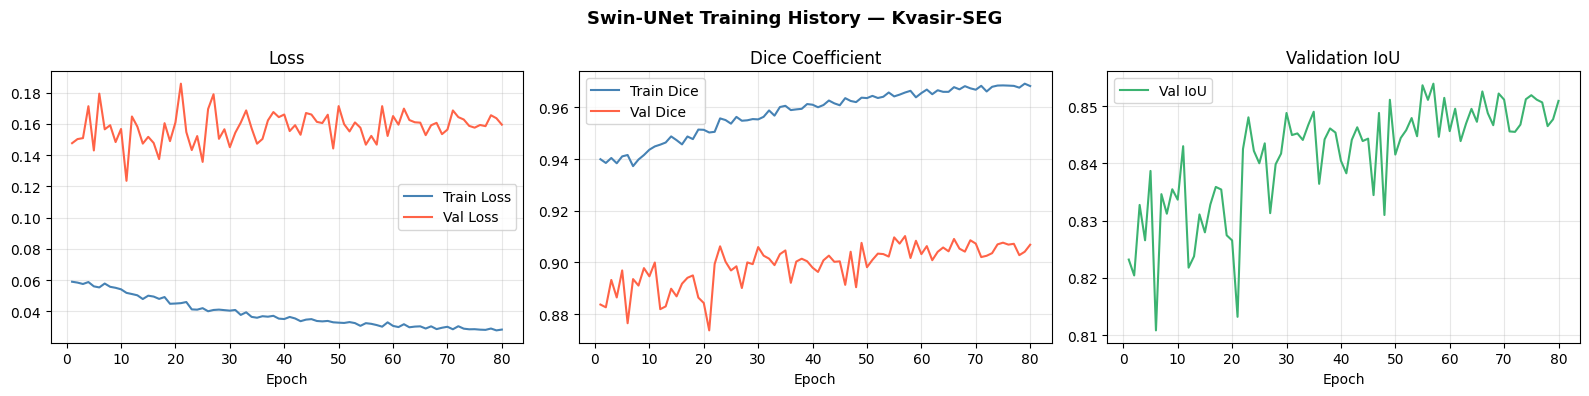

In [23]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['train_dice'], label='Train Dice', color='steelblue')
axes[1].plot(epochs, history['val_dice'],   label='Val Dice',   color='tomato')
axes[1].set_title('Dice Coefficient')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['val_iou'], label='Val IoU', color='mediumseagreen')
axes[2].set_title('Validation IoU')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Swin-UNet Training History — Kvasir-SEG', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 13: Test Set Evaluation

In [24]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
print('Best checkpoint loaded ✓')

test_metrics = evaluate(model, test_loader, criterion, DEVICE)

print('\n' + '='*50)
print('  Swin-UNet — Test Set Results')
print('='*50)
print(f"  Dice Coefficient : {test_metrics['dice']:.4f}")
print(f"  IoU (Jaccard)    : {test_metrics['iou']:.4f}")
print(f"  Pixel Accuracy   : {test_metrics['pixel_acc']:.4f}")
print(f"  Test Loss        : {test_metrics['loss']:.4f}")
print('='*50)

Best checkpoint loaded ✓



  Swin-UNet — Test Set Results
  Dice Coefficient : 0.9158
  IoU (Jaccard)    : 0.8614
  Pixel Accuracy   : 0.9772
  Test Loss        : 0.0972


## Step 14: Comparison with SETR-PUP (Family 3)

Direct comparison between Family 3 and Family 5 — same dataset, same split, same loss, same metrics.

In [25]:
# Fill in your SETR-PUP results from the Family 3 notebook
results = {
    'SETR-PUP (Family 3)': {'Val Dice': 0.9184, 'Val IoU': 0.8613},
    'Swin-UNet (Family 5)': {'Val Dice': test_metrics['dice'], 'Val IoU': test_metrics['iou']},
}

print('\n' + '='*55)
print(f"  {'Model':<25} {'Val Dice':>10} {'Val IoU':>10}")
print('='*55)
for model_name, scores in results.items():
    print(f"  {model_name:<25} {scores['Val Dice']:>10.4f} {scores['Val IoU']:>10.4f}")
print('='*55)


  Model                       Val Dice    Val IoU
  SETR-PUP (Family 3)           0.9184     0.8613
  Swin-UNet (Family 5)          0.9158     0.8614


## Step 15: Qualitative Visualization

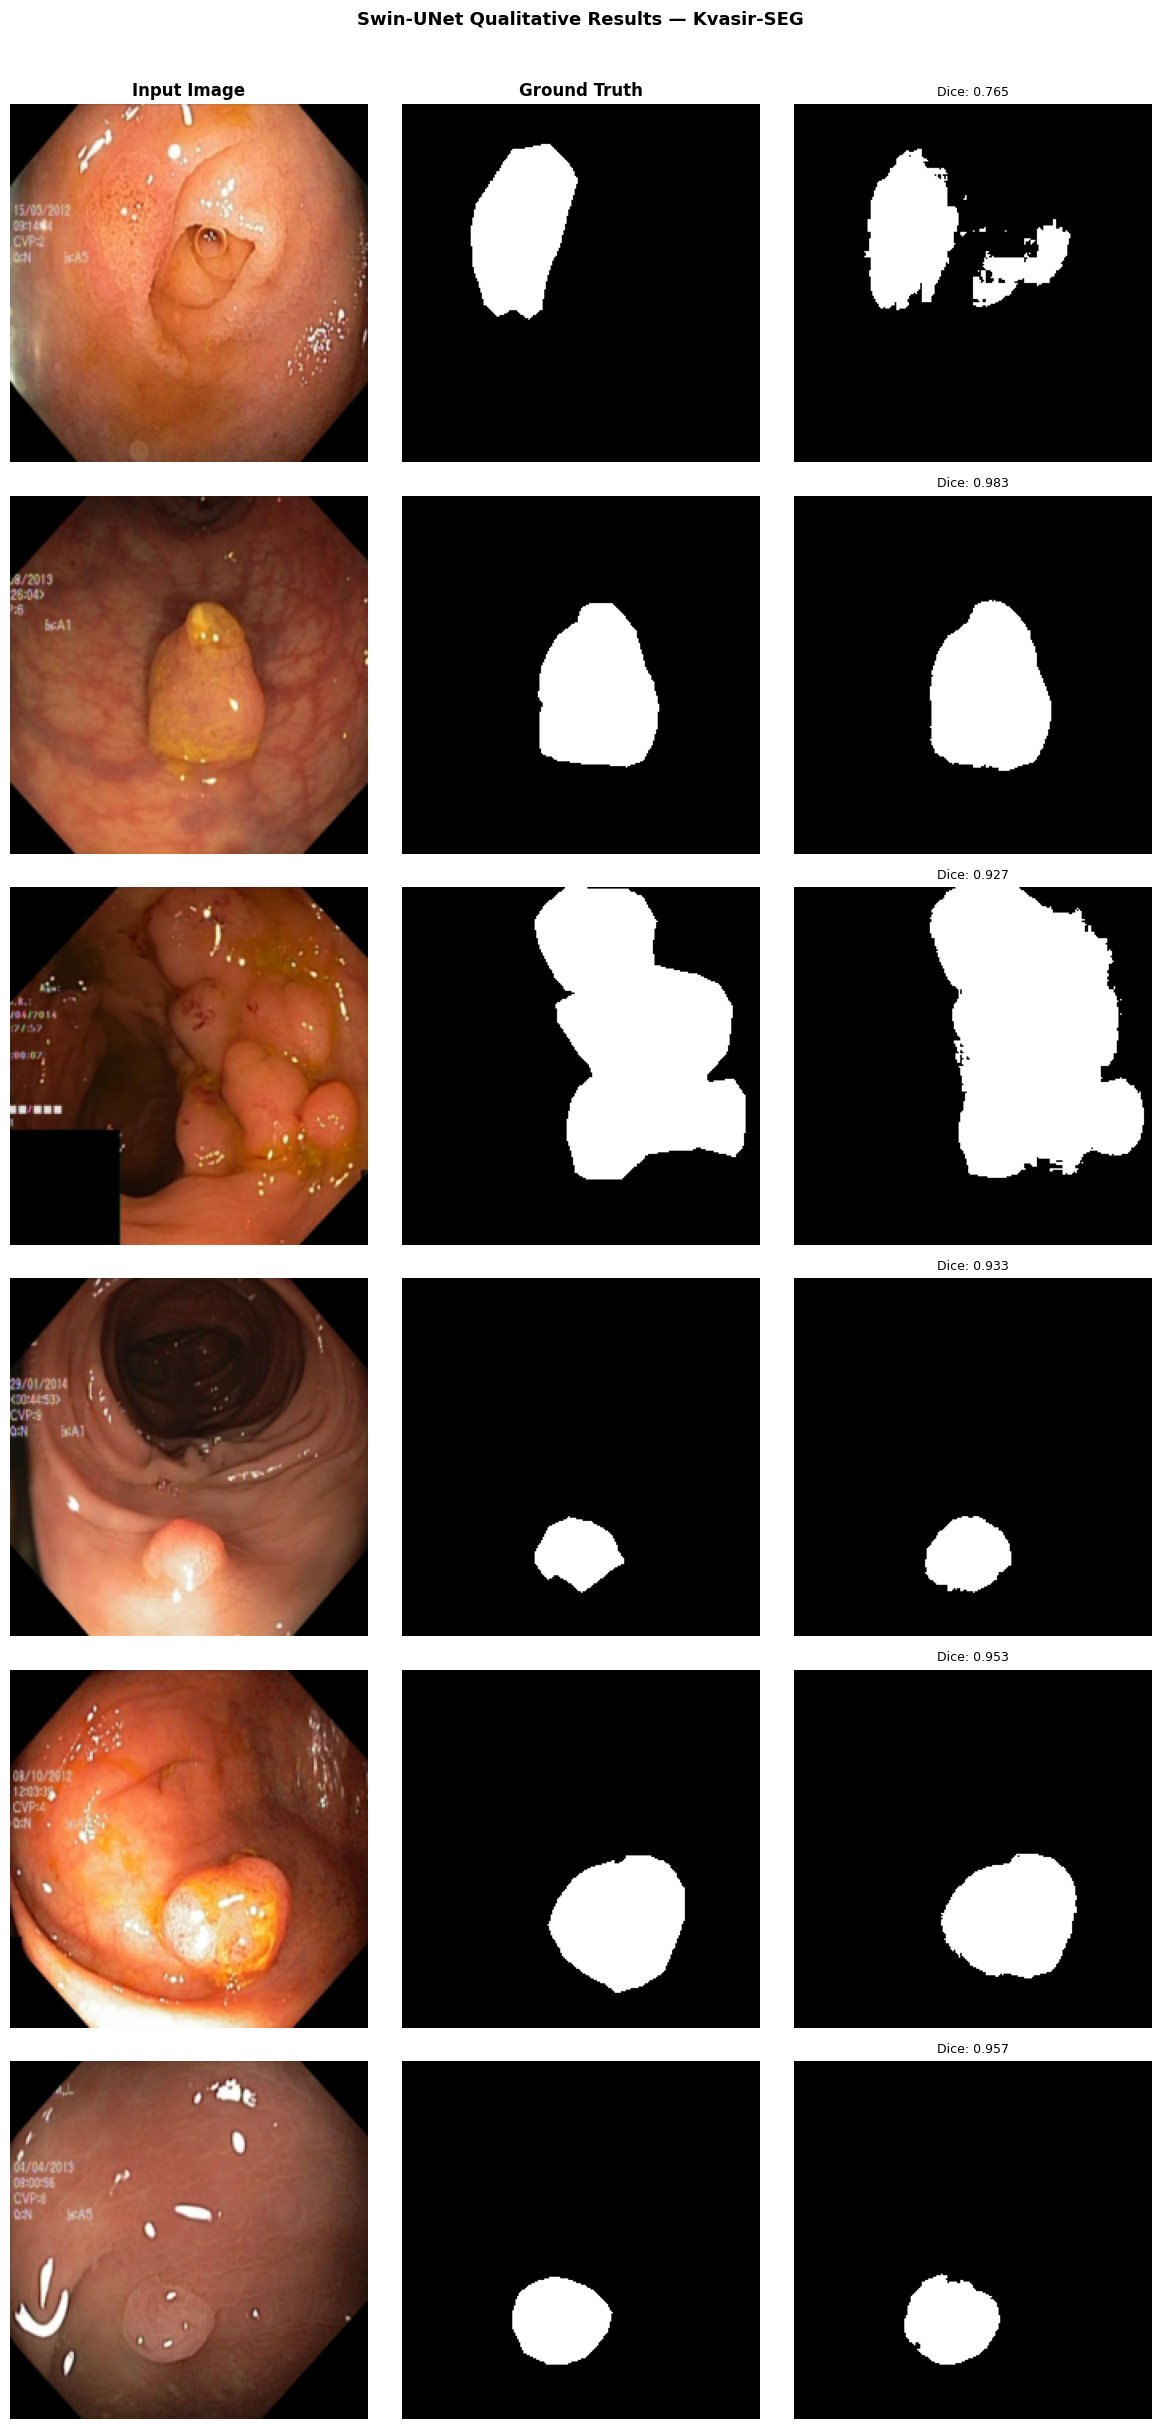

In [26]:
model.eval()
indices = random.sample(range(len(test_dataset)), 6)

fig, axes = plt.subplots(6, 3, figsize=(12, 24))
col_titles = ['Input Image', 'Ground Truth', 'Swin-UNet Prediction']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold')

with torch.no_grad():
    for row, idx in enumerate(indices):
        image, mask = test_dataset[idx]
        logit = model(image.unsqueeze(0).to(DEVICE))
        pred  = (torch.sigmoid(logit) > 0.5).float().squeeze().cpu()
        dice  = compute_metrics(logit.cpu(), mask.unsqueeze(0))['dice']

        axes[row, 0].imshow(denormalize(image).permute(1, 2, 0))
        axes[row, 0].axis('off')
        axes[row, 1].imshow(mask.squeeze(), cmap='gray')
        axes[row, 1].axis('off')
        axes[row, 2].imshow(pred, cmap='gray')
        axes[row, 2].set_title(f'Dice: {dice:.3f}', fontsize=9)
        axes[row, 2].axis('off')

plt.suptitle('Swin-UNet Qualitative Results — Kvasir-SEG',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()